In [3]:
pip install pandas matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached numpy-2.4.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 28.8 MB/s  0:00:00 eta 0:00:01
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp314-cp314-macosx_10_15_universal2.whl (2.8 MB)
Using

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

In [5]:
# Russian month abbreviations -> numbers
RU_MONTHS = {
    'янв': '01', 'фев': '02', 'мар': '03', 'апр': '04',
    'мая': '05', 'июн': '06', 'июл': '07', 'авг': '08',
    'сен': '09', 'окт': '10', 'ноя': '11', 'дек': '12'
}

def parse_ru_date(s):
    """Parse dates like 'фев/15/26 7:14 AM' -> datetime."""
    if pd.isna(s):
        return pd.NaT
    s = str(s).strip()
    for ru, num in RU_MONTHS.items():
        s = s.replace(ru + '/', num + '/')
    try:
        return pd.to_datetime(s, format='%m/%d/%y %I:%M %p')
    except Exception:
        return pd.NaT

In [8]:
# Load all CSV files from the same directory (or adjust the glob pattern)
csv_files = glob.glob(str(Path('/Users/ickostiantyn.ivanov/Documents/projects/python/tools/architecture-intelligence').resolve() / '*.csv')) or glob.glob('*.csv')
print(f'Found {len(csv_files)} CSV file(s):', csv_files)

df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f'Total tasks: {len(df)}')

Found 1 CSV file(s): ['/Users/ickostiantyn.ivanov/Documents/projects/python/tools/architecture-intelligence/example.csv']
Total tasks: 378


In [9]:
df['Обновлено_dt'] = df['Обновлено'].apply(parse_ru_date)
df['Создано_dt']  = df['Создано'].apply(parse_ru_date)
df['resolution_days'] = (df['Обновлено_dt'] - df['Создано_dt']).dt.total_seconds() / 86400
df.head(3)

,Ключ задачи,Идентификатор задачи,Резюме,Исполнитель,Идентификатор исполнителя,Статус,Обновлено,Создано,Обновлено_dt,Создано_dt,resolution_days
0,SMSGSVC-3786,1071712,[BE] NOC SM - Counter increment/decrement is n...,Eli Abraham,5e71340ed6e3cc0c3dd9e2bd,Testing Complete,фев/15/26 7:14 AM,фев/12/26 9:50 AM,2026-02-15 07:14:00,2026-02-12 09:50:00,2.891667
1,SMSGSVC-3785,1071088,NOC(staff) could not access the deleted shared...,Kiril Karpilov,5aa54417460f54375e34f5a5,Закрыто,мар/02/26 7:50 AM,фев/10/26 10:19 AM,2026-03-02 07:50:00,2026-02-10 10:19:00,19.896528
2,SMSGSVC-3767,1058344,Retrieve all/conversation took more than 15 sec,Eli Abraham,5e71340ed6e3cc0c3dd9e2bd,Закрыто,янв/22/26 7:27 PM,янв/14/26 5:47 PM,2026-01-22 19:27:00,2026-01-14 17:47:00,8.069444


In [10]:
# --- Summary ---
print(f"Total tasks : {len(df)}")
print(f"\nBy status (Статус):")
print(df['Статус'].value_counts().to_string())

Total tasks : 378

By status (Статус):
Статус
Закрыто                   367
Не начато                   6
Implementing                2
Testing Complete            1
Ready for Verification      1
Blocked (migrated 2)        1


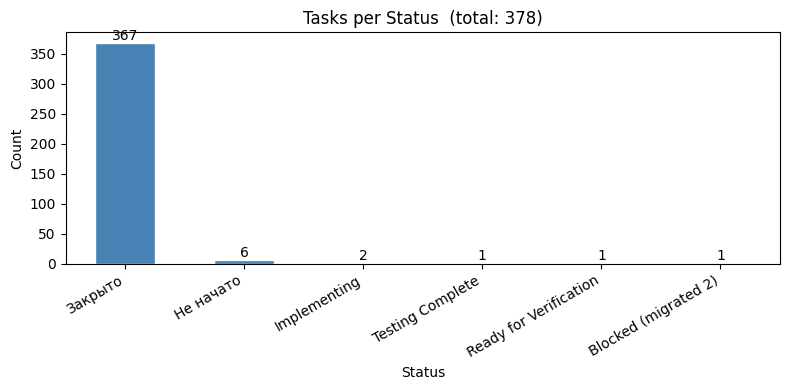

In [11]:
# --- Chart: tasks per status ---
status_counts = df['Статус'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
status_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Tasks per Status  (total: {len(df)})')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

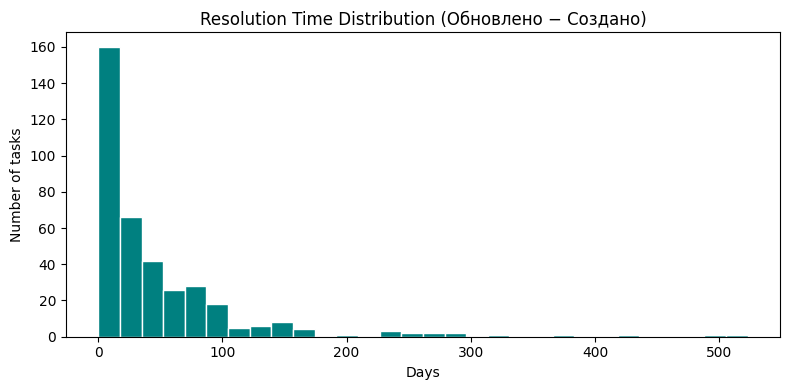

count          378.000000
mean (days)     47.786991
std             67.922257
min              0.038194
p25              9.119618
median          23.502778
p75             61.887674
max            522.836806


In [12]:
# --- Chart: resolution time distribution ---
resolved = df['resolution_days'].dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(resolved, bins=30, color='teal', edgecolor='white')
ax.set_title('Resolution Time Distribution (Обновлено − Создано)')
ax.set_xlabel('Days')
ax.set_ylabel('Number of tasks')
plt.tight_layout()
plt.show()

print(resolved.describe().rename({
    'count': 'count', 'mean': 'mean (days)', 'std': 'std',
    'min': 'min', '25%': 'p25', '50%': 'median', '75%': 'p75', 'max': 'max'
}).to_string())

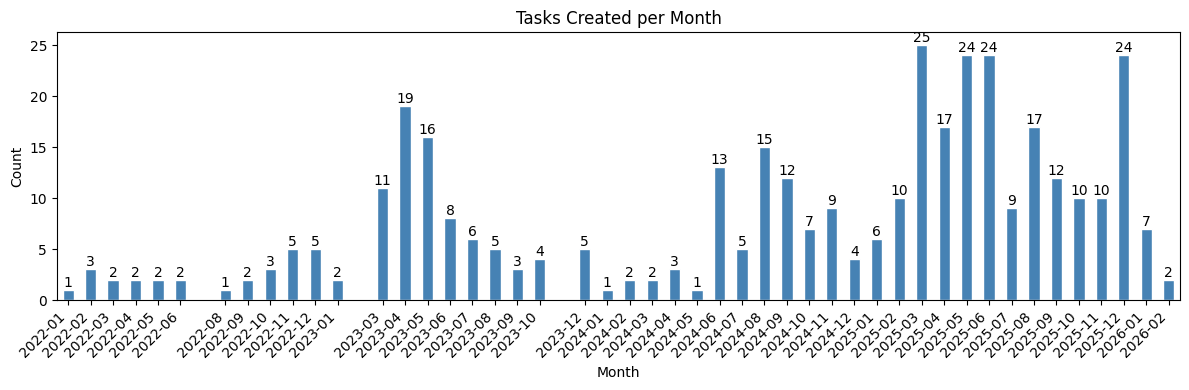

In [13]:
# --- Chart: tasks created per month ---
monthly = df['Создано_dt'].dropna().dt.to_period('M').value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Tasks Created per Month')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()